# Interactive flagging of timeseries data

## Approach and usage
Data are loaded from a .parquet file into a polars dataframe. 
Two auxiliary columns are added, namely '\_flag_' and '\_color_'.
Date are then plotted on an interactive canvas.
User can press and hold a key to determine the flag (currently, 0-3 and Esc) and pick points with the mouse.
Alternatively, user can activate the zoom tool, select an area, and flag all visible points at once by pressing a key.
User can save the data with the flags by clicking on the save button. This will rename the flag column to 'f_variable', drop the color column, and save the data as .parquet file under the level2 branch.
User can switch between variables seamlessly.

Data from level2 folder can be re-loaded and flagging continued. If user selects a file from either the level1 folder structure and a sibling level2 data file exists, additional data from the level1 data folder are added to the level2 data file, and the flagging continues in the latter.

author: joerg.klausen@meteoswiss.ch

[TODO] allow 2 variables to be plotted on a separate axis for comparison. Flagging would take place on the first axis.

In [1]:
import os
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates
# import numpy as np
import polars as pl

from ipyfilechooser import FileChooser
from ipywidgets.widgets import Dropdown
from ipywidgets import Button, Text, VBox, HBox, Output, Layout
from IPython.display import display
# import ez_flag_data
# activate the matplotlib widget for Jupyter
%matplotlib widget

# # file related configurations
root_dir = os.path.join(os.getcwd(), 'data')
source_dir = 'level1'
target_dir = 'level2'

# dataframe column label configurations
dtm = 'dtm'
flags = '_flag_'
colors = '_color_'

# other configurations
keys = {'escape': {'flag': None, 'color': 'magenta', 'meaning': 'unflagged'},
        '0': {'flag': 0, 'color': 'blue', 'meaning': 'valid'},
        '1': {'flag': 1, 'color': 'red', 'meaning': 'invalid'},
        '2': {'flag': 2, 'color': 'gray', 'meaning': 'uncertain'},
        '3': {'flag': 3, 'color': 'cyan', 'meaning': 'zero check'},
        '4': {'flag': 4, 'color': 'brown', 'meaning': 'span check'},}
flag_col_prefix = 'f_'
new_file_on_save = False

# variables to be excluded from variable select dropdown
excl_vars_general = (dtm, 'source', '_color_', '_flag_', 'f_None',)
excl_vars_ae33 = ('Inst_SN', 'DateTime_1', 'unclear', 'DateTime_2', )
excl_vars_g2401 = ('DATE', 'TIME', 'FRAC_DAYS_SINCE_JAN1', 'FRAC_HRS_SINCE_JAN1', 'JULIAN_DAYS', 'EPOCH_TIME',)
excl_vars_meteo = ('iii', 'zzzztttt',)
exclude_variables = excl_vars_general + excl_vars_ae33 + excl_vars_g2401 + excl_vars_meteo 

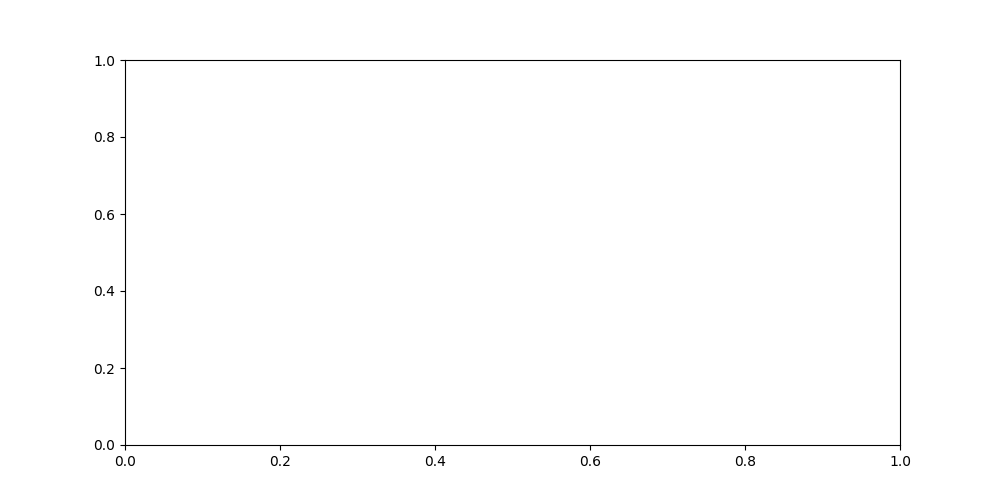

ValueError: /home/zue/users/jkl/Public/git/gawkenya/data/level1/2023/mkn_meteo_1h.parquet expected to exist, but it doesn't.

In [10]:
def on_file_chooser_read_file(chooser):
    global df, dropdown_variable_select
    # After file is selected, check if .parquet file already exists in target_dir, and if it does, 
    # add all extra data available in source to target, leaving existing additional columns in target (aka, flags) untouched.
    # if file is selected from target_dir, look for sibling file in source_dir, and proceed like-wise. 
    # open the modified target file for flagging.
    selected_file = file_chooser.selected
    if target_dir in selected_file:
        source_file = selected_file.replace(target_dir, source_dir)
        target_file = selected_file
        infobox.value = f"target dir: {target_dir}"
    elif source_dir in selected_file:
        source_file = selected_file
        target_file = selected_file.replace(source_dir, target_dir)
        infobox.value = f"source dir: {target_dir}"
    else:
        value_error = f"Please select a .parquet file from either {source_dir} or {target_dir} sub-folders."
        raise ValueError(value_error)

    if os.path.exists(target_file):
        infobox.value = f"target file: {target_file}"
        df = pl.read_parquet(source=target_file)
        if os.path.exists(source_file):
            infobox.value = f"Similar file found under '{source_dir}' and '{target_dir}'. Adding additional data from '{source_dir}' ... results will be saved under '{target_dir}'."
            df_source = pl.read_parquet(source=source_file)
            df = df_source.join(df, on=dtm, how="left")
            del(df_source)
            df = df.drop([col for col in df.columns if "_right" in col])
        else:
            # value_error = f"{source_file} expected to exist, but it doesn't."
            # raise ValueError(value_error)
            df = pl.read_parquet(source=target_file)
    else:
        infobox.value = f"source file: {source_file}"
        df = pl.read_parquet(source=source_file)

    df = df.sort(by=dtm)

    # create options for variable select dropdown widget
    dropdown_variable_select.options = [ele for ele in df.columns if ele not in exclude_variables]


def on_dropdown_value_selected(change):
    global df, sc, variable
    old = change.old
    variable = change.new

    # clear plot
    ax.cla()
    ax.set_title('ezFlag - Interactive data flagging')

    if df.select(pl.col(variable).count()).item()==0:
        infobox.value = f"No data available for {variable}"     
    elif variable and (variable != old):
        infobox.value = ""
        f_variable = f"{flag_col_prefix}{variable}"
        
        df = df.with_columns(pl.lit(keys["escape"]["color"], dtype=pl.Utf8).alias(colors))
        
        # load flags if they exist already and update colors
        if flags in df.columns:
            # <flags> column already exists, but user has switched to another variable > keep previous flags as column <{flag_col_prefix}{old}>
            # infobox.value = f"3. {old} > {variable}"
            df = df.rename({flags: f"{flag_col_prefix}{old}"})
        if f_variable in df.columns:
            # flag column already exists for the selected variable from earlier flagging > rename to <flags> to continue flagging
            df = df.rename({f_variable: flags})

            # set colors according to flags
            if colors in df.columns:
                # infobox.value = f"5. {old} > {variable}"
                for k in keys.keys():
                    if keys[k]["flag"] is not None:
                        df = df.with_columns(pl.when(pl.col(flags) == keys[k]["flag"])
                                            .then(pl.lit(keys[k]["color"]))
                                            .otherwise(pl.col(colors)).alias(colors))             
            else:
                infobox.value = f"{old} > {variable}"
                # variable has been flagged before, but is newly selected > set up colors according to existing flags
        else:
            # user has chosen a variable that has never been flagged > initialize <flags> and <colors> columns
            df = df.with_columns(pl.lit(keys["escape"]["flag"], dtype=pl.Int8).alias(flags))
            # df = df.with_columns(pl.lit(keys["escape"]["color"], dtype=pl.Utf8).alias(colors))    

        sc = ax.scatter(df[dtm], df[variable], c=df[colors], alpha=0.7, s=10, picker=5)
        ax.set_ylabel(ylabel=variable)
        fig.canvas.draw_idle()


def on_picked_flag_point(event):
    """
    event.mouseevent.key : None, Any character, shift, control, win (cf. https://matplotlib.org/stable/users/explain/figure/event_handling.html#event-attributes)
    event.mouseevent.button : 1: left, 2: middle, 3: right
    event.ind : index of point picked. NB: the index is set when the figure is created for the first time, so is unaffected by zooming.
    """
    global df

    infobox.value = f"Zoom OFF & key = '{event.mouseevent.key}'. Point with index = {event.ind} selected."
    if ax.get_navigate_mode() is None:
        if keys.get(event.mouseevent.key):
            flag = keys[event.mouseevent.key]["flag"]
            color = keys[event.mouseevent.key]["color"]
            df[event.ind, flags] = flag
            df[event.ind, colors] = color
            sc.set_color(df[colors])
            fig.canvas.draw_idle()
        else:
            infobox.value = f"Zoom OFF & point picked, but key '{event.mouseevent.key}' not assigned." 


def on_key_pressed_flag_points(event):
    global df, variable

    infobox.value = f"Zoom ON & key = '{event.key}' pressed."
    if ax.get_navigate_mode() == "ZOOM":
        if keys.get(event.key):
            flag = keys[event.key]["flag"]
            color = keys[event.key]["color"]
            meaning = keys[event.key]["meaning"]
            infobox.value = f"flag = {flag} ({meaning})"
            zoom_xlim = ax.get_xlim()
            # zoom_xlim = [matplotlib.dates.num2date(x).replace(tzinfo=None) for x in zoom_xlim]
            zoom_xlim = [matplotlib.dates.num2date(x, tz=None).replace(tzinfo=None) for x in zoom_xlim]
            zoom_ylim = ax.get_ylim()
            condition = ((pl.col(dtm).dt.replace_time_zone(None) > zoom_xlim[0]) & (pl.col(dtm).dt.replace_time_zone(None) < zoom_xlim[1])
                        & (pl.col(variable) > zoom_ylim[0]) & (pl.col(variable) < zoom_ylim[1]))
            df = df.with_columns([pl.when(condition)
                                .then(pl.lit(color))
                                .otherwise(pl.col(colors)).alias(colors),
                                pl.when(condition)
                                .then(pl.lit(flag))
                                .otherwise(pl.col(flags)).alias(flags),])
            sc.set_color(df[colors])
            fig.canvas.draw_idle()
        else:
            infobox.value = f"Zoom ON, but key '{event.key}' not assigned."


def on_clicked_save_data(event):
    global df

    if dropdown_variable_select.value is not None:
        # rename flag column, drop color column
        df = df.rename({flags: f"{flag_col_prefix}{variable}"})
        df = df.drop(colors)

    # set file name for level2 data file and save file
    target_file = os.path.join(file_chooser.selected_path.replace(source_dir, target_dir), file_chooser.selected_filename)
    if new_file_on_save:
        if os.path.exists(target_file):
            infobox.value = f"'{os.path.basename(target_file)}' exists already. A unique name will be created."
            target_file += f"-{datetime.now().strftime('%Y%m%d%H%M%S')}"
    os.makedirs(os.path.dirname(target_file), exist_ok=True)
    infobox.value = f"Saving to '{target_file}'."
    df.write_parquet(target_file)
    ax.cla()
    return

# prepare figure and create widget for display
fig = plt.figure(figsize=(10, 5))
ax = fig.subplots()

# create input widgets
file_chooser = FileChooser(
    select_desc="Select file", 
    change_desc="Select file",
    path=os.path.join(root_dir, source_dir), 
    filter_pattern="*.parquet",
    layout=Layout(width='700px'))
dropdown_variable_select = Dropdown(
    value=None, 
    options=[], 
    description="Variable")
button_save_data = Button(description="Save data", layout=Layout(width='80px'))

# create layout
design = 2
if design==1:
    infobox = Text(description="NB", layout=Layout(width='700px'))
    layout = VBox([file_chooser, dropdown_variable_select, infobox, button_save_data, Output()]) 
else:
    infobox = Text(layout=Layout(width='800px'))
    layout = VBox([file_chooser, dropdown_variable_select, HBox([button_save_data, infobox]), Output()]) 
    
# # connect events
button_save_data.on_click(on_clicked_save_data)
dropdown_variable_select.observe(on_dropdown_value_selected, names='value')
cid_pick = fig.canvas.mpl_connect('pick_event', on_picked_flag_point)
cid_key_press = fig.canvas.mpl_connect('key_press_event', on_key_pressed_flag_points)

# Register callback function
file_chooser.register_callback(on_file_chooser_read_file)

# Display widgets
display(layout)

# display the plot
plt.show()